In [11]:
%matplotlib ipympl
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import cmap

import scipy.ndimage
import seaborn as sns

from scipy.stats import entropy

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "figure.constrained_layout.use": True,
})

def detect_upstates(
    spikes: nap.TsGroup,
    bin_size = 0.01,
    percentile = 80,
    merge_thr = 0.1,
    short_thr = 0.04,
    long_thr = 2,
    ) -> nap.IntervalSet:
    x = spikes.count(bin_size=bin_size).sum(axis=1)
    x = x / bin_size
    x = x.smooth(std=2 * bin_size)
    thr = np.percentile(x, q=percentile)

    up_states = x.threshold(thr, method='above').time_support
    up_states = up_states.merge_close_intervals(threshold=merge_thr)
    up_states = up_states.drop_short_intervals(threshold=short_thr)
    up_states = up_states.drop_long_intervals(threshold=long_thr)
    return up_states

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()
seq_cmap = cmap.Colormap('cmasher:tropical').to_mpl()

In [12]:
mouse_id        = "107b"
data_dir        = INTERIM_DIR / mouse_id

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
hd_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
virtual_hds     = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "virtual_hd.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")

nrem            = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])

# compute HD preferred angle
tcs = nap.compute_tuning_curves(hd_units, head_direction, bins=24, fs=1000, feature_names=['hd'])
tcs.values = scipy.ndimage.gaussian_filter1d(tcs.values, sigma=1, axis=1, mode="wrap")
pref_angle = tcs.idxmax(dim='hd').to_numpy().squeeze()
hd_order = np.argsort(pref_angle)

<Axes: ylabel='Count'>

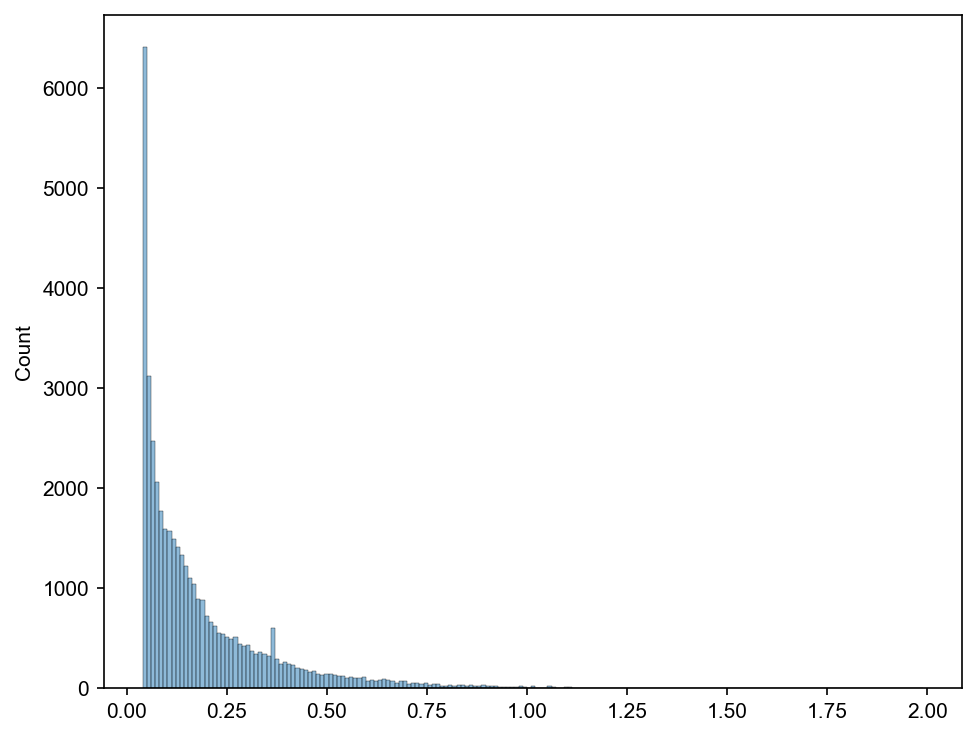

In [5]:
spikes = hd_units.restrict(nrem)
up_states = detect_upstates(spikes)
sns.histplot(np.diff(up_states.values), legend=False)

In [14]:
x = spikes.count(bin_size=10, time_units='ms').sum(axis=1)
x = x / 0.01
x = x.smooth(std=20, time_units='ms')
thr = np.percentile(x, q=80)

In [16]:
ep = nrem[52]
print(ep)

hd_spikes = hd_units.restrict(ep)
up_eps = up_states.intersect(ep)
x_ep = x.restrict(ep)
vhd = virtual_hds.restrict(ep)

hd_unit_ids = np.array(hd_spikes.keys())
hd_unit_ids = hd_unit_ids[np.argsort([pref_angle[n].item() for n in hd_unit_ids])]

bin_size = 0.005

decoded, p_feature = nap.decode_bayes(
    tuning_curves=tcs,
    data=hd_units,
    epochs=ep,
    bin_size=bin_size,
    sliding_window_size=6
    )

# normalized_entropy = nap.Tsd(
#     t=hd_units.count(bin_size=bin_size, ep=ep).t,
#     d=entropy(p_feature.d, axis=1) / np.log(tcs.shape[1])
#     )

# valid_eps = normalized_entropy.threshold(0.8, method='below').time_support
# print(valid_eps.tot_length())

  index    start    end
      0    23119  23190
shape: (1, 2), time unit: sec.


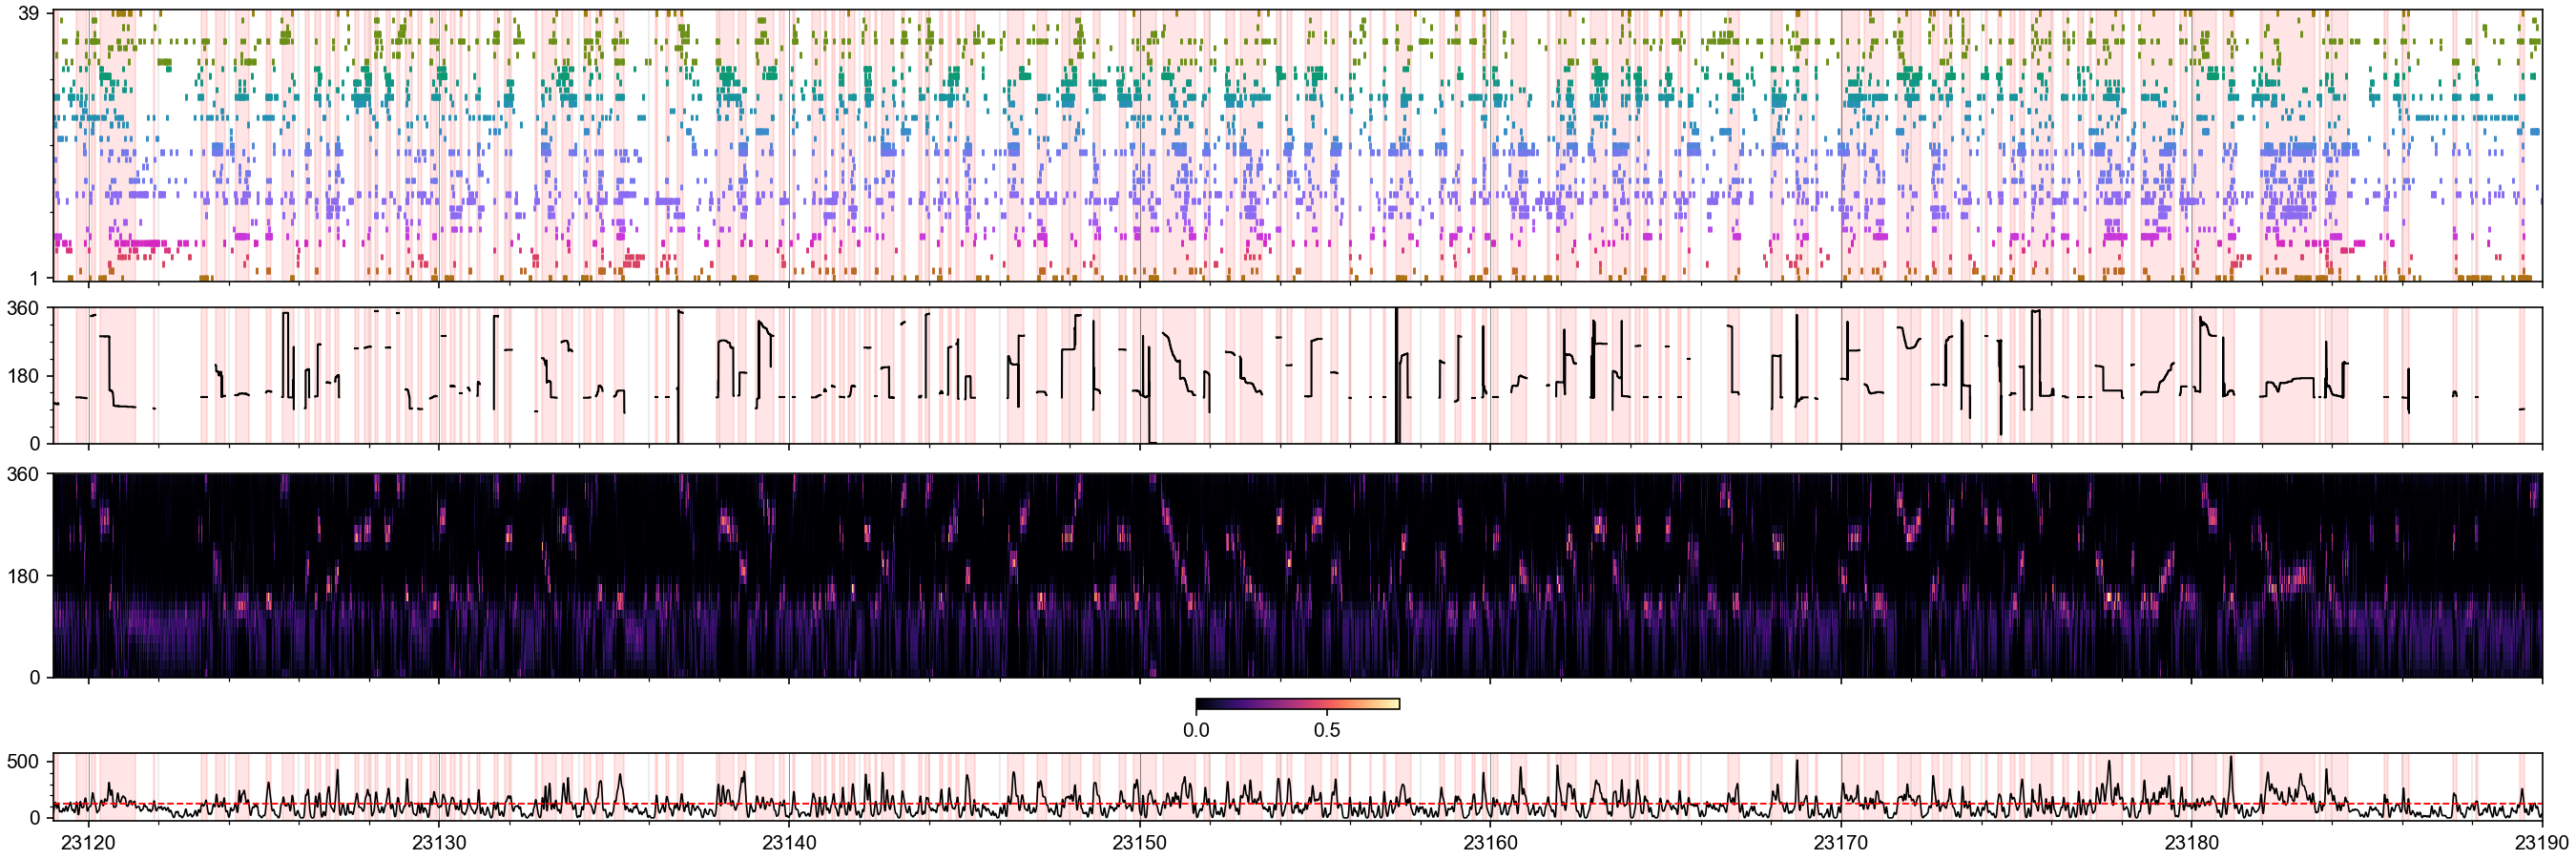

In [17]:
f, ax = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(18, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 1.5, 0.5]})

for row, uid in enumerate(hd_unit_ids, start=1):
    pa = pref_angle[uid].item()
    ax[0].eventplot(
        hd_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.9,
        linewidths=1.4,
        colors=[cyclic_cmap(pa / 360)],
        alpha=1,
    )

for up_ep in up_eps:
    ax[1].plot(vhd.restrict(up_ep), color='k', linewidth=1)

mesh = ax[2].pcolormesh(
    p_feature.t,
    p_feature.columns.to_numpy(dtype=float),
    p_feature.d.T,
    shading='auto',
    cmap='magma',
    vmin=0,
)

f.colorbar(mesh, ax=ax[2], orientation='horizontal', aspect=20, fraction=0.05)

ax[3].plot(x_ep, linewidth=0.8, color='k')
ax[3].axhline(thr, linewidth=0.9, color='r', linestyle='--')

for a in ax:
    if a == ax[2]:
        continue
    a.minorticks_on()
    a.grid(axis='x', which='major', color='0.1', alpha=0.5, linewidth=0.5)
    a.grid(axis='x', which='minor', color='0.3', alpha=0.5, linewidth=0.2)
    for start, end in up_eps.values:
        a.axvspan(start, end, color='r', alpha=0.1)
    # for start, end in c_eps.values:
    #     a.axvspan(start, end, color='b', alpha=0.1)

ax[0].set_ylim(0.5, len(hd_unit_ids) + 0.5)
ax[1].set_ylim((0, 360))
ax[2].set_ylim((0, 360))

ax[0].set_yticks([1, len(hd_unit_ids)])
ax[1].set_yticks([0, 180, 360])
ax[2].set_yticks([0, 180, 360])

plt.show()

(23146.0, 23156.0)

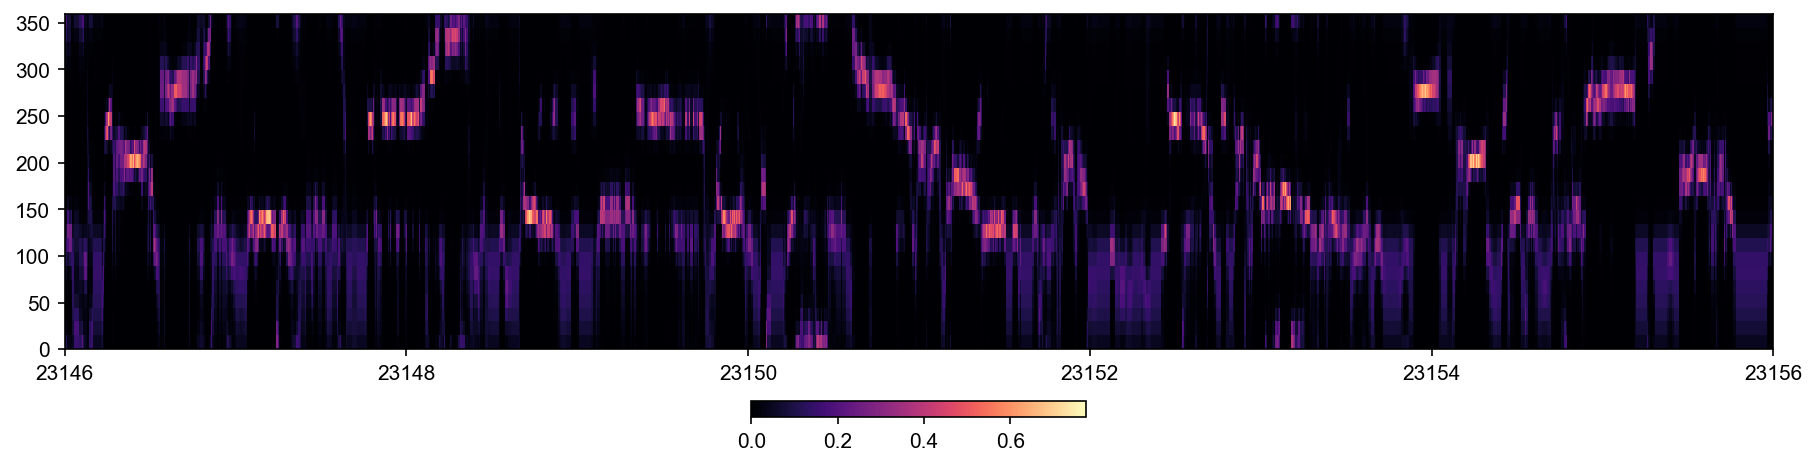

In [55]:
f, ax = plt.subplots(figsize=(12, 3))

mesh = ax.pcolormesh(
    p_feature.t,
    p_feature.columns.to_numpy(dtype=float),
    p_feature.d.T,
    shading='auto',
    cmap='magma',
    vmin=0,
    )

f.colorbar(mesh, ax=ax, orientation='horizontal', aspect=20, fraction=0.1)

ax.set_xlim((23146, 23156))